# LeafArea — leaf area estimation for six Andean fruit species (R, CPU)

Reproduction of: **"LeafArea Package: A Tool for Estimating Leaf Area in Andean Fruit Species"**,
*International Journal of Plant Biology* 15(1):9 (2024), DOI [10.3390/ijpb15010009](https://doi.org/10.3390/ijpb15010009).

- **Author code:** R package `velasquez-vasconez/LeafArea`, pinned commit `76552f1ef7b17581e624b728020b4da3fa5f7b2b` (verified first-author repository, 2023-11-25).
- **Scope:** the README worked example — outlier treatment + `mice` imputation of a 12-row species/length/width table (`outlier_treatment_mice`), then in-session training of the Random Forest (`calculate_LeafArea_rf`, README path) and XGBoost (`calculate_LeafArea_xgb`, the abstract's best-performing model) regressions on the author-bundled training workbook `inst/tests/testdata/df.xlsx`, with test/train RMSE/MAE/MAPE/R² and predictions for the example leaves.
- **Not reproduced:** the GLM/GLMM variants, the full 4-way model comparison, and per-species published accuracy figures (article full text is inaccessible behind MDPI's 403; see report). A one-example run does not verify dataset-level published accuracy.
- **Language note / 言語について:** This notebook uses a Python kernel only as a **launcher**: every scientific step is the author's unmodified R package executed through `Rscript`. The orchestration, the `png()` device wrapper around the author's own boxplots, and the added comparison graph are AI-generated glue; the author did not provide this Colab notebook.
  **Python は R を起動するためだけのランチャーです。科学計算はすべて著者自身の R パッケージで実行されます。**
- **License:** DESCRIPTION declares *MIT + file LICENSE*; the GitHub UI reports "Other". The 46-byte `LICENSE` names "LeafArea authors", year 2023. Recorded as an ambiguity, not resolved here.
- **Data boundary:** the bundled workbook `df.xlsx` is used **only inside Colab**; its integrity is checked against the pinned Git blob SHA `a873ca5445d60b0db598f0fce34d6c88d2555e1a` (58996 bytes).

**Expected runtime:** ~25–50 min total (a pinned xgboost 1.7.8.1 source build of ~15–35 min dominates; the rest is fast binary setup); downloads well under 300 MiB; **CPU runtime is sufficient — no GPU is required or used.**

## 実行方法（Run all）
1. メニューから **ランタイム → すべてのセルを実行** を選択してください。
2. 推奨ランタイム: **CPU**（GPU は不要です）。
3. セットアップ（R パッケージのバイナリインストール）に約 5–15 分、解析自体は数分です。

## 1. Environment check — 環境確認

**Cell purpose:** verify that this Colab runtime provides `Rscript` (Colab runtime images include R) and print the R version. Expected: R ≥ 4.x; the author's package is pure R with no compiled code, so any recent R works.

**Cell purpose (JA):** このランタイムに R が同梱されていることを確認し、バージョンを表示します。GPU は不要です。

In [ ]:
import subprocess

r = subprocess.run(["Rscript", "-e", 'cat(R.version.string, "\n")'],
                   capture_output=True, text=True, timeout=180)
print(r.stdout.strip() or r.stderr.strip())
assert r.returncode == 0, "Rscript is not available on this runtime; select a standard Colab runtime image."
R_VERSION = r.stdout.strip()

R version 4.6.1 (2026-06-24)


## 2. Install the author's R dependencies — 依存Rパッケージのインストール

**Cell purpose:** install the packages the pinned `LeafArea` DESCRIPTION imports — `mice, caret, readxl, randomForest, MuMIn, nlme, performance` — plus `remotes`. Installation uses the **Posit Package Manager (P3M) Ubuntu binary mirror for noble**, which serves precompiled binaries for this runtime's R version, avoiding 20–40 min of source compilation. `xgboost` is deliberately **not** installed here; it is pinned separately in the next cell (compatibility fix, documented there). Expected output: streamed `installing *binary* package ...` lines ending with a version list. This is the longest cell (~5–10 min).

**Cell purpose (JA):** DESCRIPTION の依存パッケージを Posit 社のバイナリリポジトリから高速にインストールします（コンパイル不要・約5〜10分）。xgboost は次セルで別途ピン留めします。

In [ ]:
import pathlib, subprocess, time

script = '''options(repos = c(P3M = "https://packagemanager.posit.co/cran/__linux__/noble/latest"),
        HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
                                paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))

pkgs <- c("readxl", "randomForest", "caret", "mice", "MuMIn", "performance", "remotes")
install.packages(pkgs, Ncpus = 2)
cat("\n--- installed versions ---\n")
for (p in pkgs) cat(p, as.character(packageVersion(p)), "\n")
'''
pathlib.Path('/content/install_leafarea_deps.R').write_text(script)
t0 = time.time()
r = subprocess.run(["Rscript", "/content/install_leafarea_deps.R"], timeout=2400)
print(f"\n[dependencies install rc={r.returncode} elapsed={time.time()-t0:.0f}s]")
assert r.returncode == 0, "R dependency installation failed; see streamed output above."



[dependencies install rc=0 elapsed=24s]


## 3. Pin xgboost 1.7.8.1 (compatibility fix) — xgboost のバージョン固定

**Cell purpose:** install **xgboost 1.7.8.1** (the last release of the 1.x series the author's 2023 code was written against) from the pinned CRAN archive URL, compiled from source inside Colab. **Why:** the first validation attempt of this notebook showed that caret's `xgbTree` resampling fails with current xgboost 3.x (every resample returned NA metrics, then `Error: Stopping`); the author's `calculate_LeafArea_xgb()` predates the xgboost 2/3 API. Pinning the author-era xgboost keeps the author's R code **unmodified**. Expected: a long streamed C++ build (~15–35 min on CPU) ending with `xgboost: 1.7.8.1`.

**Cell purpose (JA):** 著者コード（2023年）は xgboost 1.x 前提のため、初回検証で確認された xgboost 3.x との非互換（caret の xgbTree が全foldでNA）を避けるため、1.7.8.1 を CRAN アーカイブから固定インストールします（ソースビルド約15〜35分）。著者のRコードは一切変更しません。

In [ ]:
import pathlib, subprocess, time

script = '''url <- "https://cran.r-project.org/src/contrib/Archive/xgboost/xgboost_1.7.8.1.tar.gz"
download.file(url, "/content/xgboost_1.7.8.1.tar.gz", mode = "wb")
install.packages("/content/xgboost_1.7.8.1.tar.gz", repos = NULL, type = "source")
cat("xgboost:", as.character(packageVersion("xgboost")), "\n")
stopifnot(packageVersion("xgboost") == "1.7.8.1")
'''
pathlib.Path('/content/install_xgboost_pinned.R').write_text(script)
t0 = time.time()
r = subprocess.run(["Rscript", "/content/install_xgboost_pinned.R"], timeout=3600)
print(f"\n[pinned xgboost install rc={r.returncode} elapsed={time.time()-t0:.0f}s]")
assert r.returncode == 0, "Pinned xgboost installation failed; see streamed output above."



[pinned xgboost install rc=0 elapsed=585s]


## 4. Install the pinned LeafArea package — 著者パッケージの固定コミットインストール

**Cell purpose:** install the author's package **exactly at commit `76552f1ef7b17581e624b728020b4da3fa5f7b2b`** with `remotes::install_github(..., ref=...)` (this is the documented install route in the paper's README, pinned to the verified revision). Then verify the package loads and locate the bundled training workbook via the same `system.file()` call the author's functions use. Expected: `LeafArea` version printed and a `/usr/local/lib/R/site-library/...` workbook path with **58,996 bytes**.

**Cell purpose (JA):** 論文 README のインストール手順に従い、検証済みコミットに固定してインストールします。バンドルされた学習データ `df.xlsx` のパスとサイズ（58,996 バイト）を確認します。

In [ ]:
import pathlib, subprocess, time

script = '''options(repos = c(P3M = "https://packagemanager.posit.co/cran/__linux__/noble/latest"),
        HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
                                paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))

remotes::install_github("velasquez-vasconez/LeafArea",
                        ref = "76552f1ef7b17581e624b728020b4da3fa5f7b2b",
                        upgrade = "never")
library(LeafArea)
cat("LeafArea version:", as.character(packageVersion("LeafArea")), "\n")
fp <- system.file("tests", "testdata", "df.xlsx", package = "LeafArea")
cat("Bundled data path: ", fp, "\n", sep = "")
cat("Bundled data size: ", file.info(fp)$size, " bytes\n", sep = "")
writeLines(fp, "/content/df_xlsx_path.txt")
'''
pathlib.Path('/content/install_leafarea.R').write_text(script)
t0 = time.time()
r = subprocess.run(["Rscript", "/content/install_leafarea.R"], timeout=1800)
print(f"\n[LeafArea install rc={r.returncode} elapsed={time.time()-t0:.0f}s]")
assert r.returncode == 0, "Pinned LeafArea installation failed; see streamed output above."



[LeafArea install rc=0 elapsed=23s]


## 5. Verify the bundled training data — 学習データの完全性検証

**Cell purpose:** compute the SHA-256 and Git blob SHA-1 of the downloaded `df.xlsx` inside Colab and compare with the pinned repository tree metadata (blob `a873ca5445d60b0db598f0fce34d6c88d2555e1a`, 58996 bytes). This proves the workbook used for training is byte-identical to the author's bundled file at the pinned commit. Expected: both hashes match.

**Cell purpose (JA):** ダウンロードされた `df.xlsx` のハッシュを計算し、固定コミットの Git blob SHA（a873ca5445d60b0db598f0fce34d6c88d2555e1a・58996 バイト）と一致することを検証します。

In [ ]:
import hashlib, pathlib

data_path = pathlib.Path("/content/df_xlsx_path.txt").read_text().strip()
data = pathlib.Path(data_path).read_bytes()
blob_sha = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
sha256 = hashlib.sha256(data).hexdigest()
print(f"file: {data_path}")
print(f"size: {len(data)} bytes (expected 58996)")
print(f"git blob sha1: {blob_sha}")
print(f"sha256:        {sha256}")
assert len(data) == 58996, "df.xlsx size differs from the pinned commit"
assert blob_sha == "a873ca5445d60b0db598f0fce34d6c88d2555e1a", "df.xlsx does not match the pinned Git blob"
print("VERIFIED: byte-identical to velasquez-vasconez/LeafArea@" + "76552f1ef7b17581e624b728020b4da3fa5f7b2b" + " inst/tests/testdata/df.xlsx")

file: /usr/local/lib/R/site-library/LeafArea/tests/testdata/df.xlsx
size: 58996 bytes (expected 58996)
git blob sha1: a873ca5445d60b0db598f0fce34d6c88d2555e1a
sha256:        f1dc1517bfac468e5f0420f5db9a86050168c0c4c7033aeaea40c3160aa08550
VERIFIED: byte-identical to velasquez-vasconez/LeafArea@76552f1ef7b17581e624b728020b4da3fa5f7b2b inst/tests/testdata/df.xlsx


## 6. Preview the actual training input — 学習データのプレビュー

**Cell purpose:** read the verified workbook with the author's own loader path (`readxl::read_excel`) and print its dimensions, column names, first rows, and numeric summary — the human-readable input preview required before any modeling. Expected: a few hundred leaves with species labels `sp` plus leaf dimensions and the measured `LeafArea` target. Column names are printed from the actual data (not assumed). A CSV copy is written for reference.

**Cell purpose (JA):** 著者と同じ `readxl` 経由で学習データを読み込み、次元・列名・先頭行・要約統計を表示します（実データから列名を確認）。

In [ ]:
import pathlib, subprocess

script = '''library(LeafArea)
fp <- system.file("tests", "testdata", "df.xlsx", package = "LeafArea")
df <- readxl::read_excel(fp)
cat("dimensions (rows x cols):", nrow(df), "x", ncol(df), "\n")
cat("columns:", paste(names(df), collapse = ", "), "\n\n")
print(utils::head(df, 8))
cat("\nnumeric summary:\n")
print(summary(df[, sapply(df, is.numeric)]))
write.csv(df, "/content/leafarea_training_data.csv", row.names = FALSE)
'''
pathlib.Path('/content/preview_input.R').write_text(script)
r = subprocess.run(["Rscript", "/content/preview_input.R"], capture_output=True, text=True, timeout=300)
print(r.stdout)
assert r.returncode == 0, r.stderr[-1500:]

dimensions (rows x cols): 868 x 6 
columns: sp, LeafLength, LeafWidth, LeafArea, sqrt_Length_Width, sqrt_LeafArea 

# A tibble: 8 × 6
  sp           LeafLength LeafWidth LeafArea sqrt_Length_Width sqrt_LeafArea
  <chr>             <dbl>     <dbl>    <dbl>             <dbl>         <dbl>
1 S. quitoense       66.5      55.7    2685.              60.9          51.8
2 S. quitoense       67.5      51.5    2533.              59.0          50.3
3 S. quitoense       59.3      54.6    2532.              56.9          50.3
4 S. quitoense       60        55      2414.              57.4          49.1
5 S. quitoense       59        55      2072.              57.0          45.5
6 S. quitoense       63        53      2062.              57.8          45.4
7 S. quitoense       65        51      2009.              57.6          44.8
8 S. quitoense       58        47      1913.              52.2          43.7

numeric summary:
   LeafLength      LeafWidth        LeafArea         sqrt_Length_Width
 Min.  

## 7. README example, part 1 — outlier treatment + mice imputation — 外れ値処理と補完

**Cell purpose:** run the README's worked example **verbatim**: build the 12-row example table (two *S. quitoense*/*S. betaceum* leaves sets with one injected outlier `LL=200`, one `LW=45`, and missing values), then call the author's `outlier_treatment_mice()`. The function removes IQR outliers (multiplier 1.5) and imputes the remaining `NA`s with `mice`. The author's function also draws before/after boxplots; the AI-generated glue only opens a PNG device around that unmodified call. Expected console: `Outliers removed from LeafLength : 200` and `Outliers removed from LeafWidth : 45`, followed by the `mice` iteration log — matching the README's reference output.

**Cell purpose (JA):** README の例をそのまま実行します。IQR 外れ値除去（LeafLength から 200、LeafWidth から 45）と mice による補完を行い、著者関数自身が描く箱ひげ図を PNG 保存します。

In [ ]:
import pathlib, subprocess

script = '''library(LeafArea)
df <- data.frame(
   Culture = c("S. quitoense", "S. quitoense", "S. quitoense", "S. quitoense",
               "S. quitoense", "S. quitoense", "S. betaceum", "S. betaceum",
               "S. betaceum", "S. betaceum", "S. betaceum", "S. betaceum"),
   LL = c(25, 27, 200, 56, NA, 56, 25, 27, 28, 56, 56, 56),
   LW = c(45, 56, 57, 53, 54, NA, 57, 56, 57, 53, 54, 55)
 )
sp <- df$Culture
LeafLength <- df$LL
LeafWidth <- df$LW
df_example <- data.frame(sp, LeafLength, LeafWidth)
dir.create("/content/outlier_boxplots", showWarnings = FALSE)
png("/content/outlier_boxplots/boxplot%02d.png", width = 900, height = 650, res = 110)
df_result_outlier <- LeafArea::outlier_treatment_mice(df_example)
dev.off()
cat("\nExample table after outlier removal + mice imputation:\n")
print(df_result_outlier)
write.csv(df_result_outlier, "/content/example_outlier_treated.csv", row.names = FALSE)
'''
pathlib.Path('/content/example_outlier.R').write_text(script)
r = subprocess.run(["Rscript", "/content/example_outlier.R"], capture_output=True, text=True, timeout=900)
print(r.stdout)
assert r.returncode == 0, r.stderr[-1500:]

Outliers removed from LeafLength : 200 
Outliers removed from LeafWidth : 45 

 iter imp variable
  1   1  LeafLength  LeafWidth
  1   2  LeafLength  LeafWidth
  1   3  LeafLength  LeafWidth
  1   4  LeafLength  LeafWidth
  1   5  LeafLength  LeafWidth
  2   1  LeafLength  LeafWidth
  2   2  LeafLength  LeafWidth
  2   3  LeafLength  LeafWidth
  2   4  LeafLength  LeafWidth
  2   5  LeafLength  LeafWidth
  3   1  LeafLength  LeafWidth
  3   2  LeafLength  LeafWidth
  3   3  LeafLength  LeafWidth
  3   4  LeafLength  LeafWidth
  3   5  LeafLength  LeafWidth
  4   1  LeafLength  LeafWidth
  4   2  LeafLength  LeafWidth
  4   3  LeafLength  LeafWidth
  4   4  LeafLength  LeafWidth
  4   5  LeafLength  LeafWidth
  5   1  LeafLength  LeafWidth
  5   2  LeafLength  LeafWidth
  5   3  LeafLength  LeafWidth
  5   4  LeafLength  LeafWidth
  5   5  LeafLength  LeafWidth
null device 
          1 

Example table after outlier removal + mice imputation:
             sp LeafLength LeafWidth
1  S. qu

**Cell purpose:** display the saved boxplots that the author's `outlier_treatment_mice()` drew. Because the author's function sets a 2x2 panel layout (`par(mfrow=c(2,2))`), all four base-graphics boxplots land on a single PNG page: top row = *before* outlier removal (LeafLength left, LeafWidth right), bottom row = *after*. These are the author function's own diagnostic plots for the example input, rendered through the PNG wrapper. Expected: the after panels no longer show the injected outliers (200 for LeafLength, 45 for LeafWidth).

**Cell purpose (JA):** 著者関数が出力した箱ひげ図（1ページに処理前後の4パネル）を表示します。

[outlier_treatment_mice() boxplots — single page: top row before removal, bottom row after]


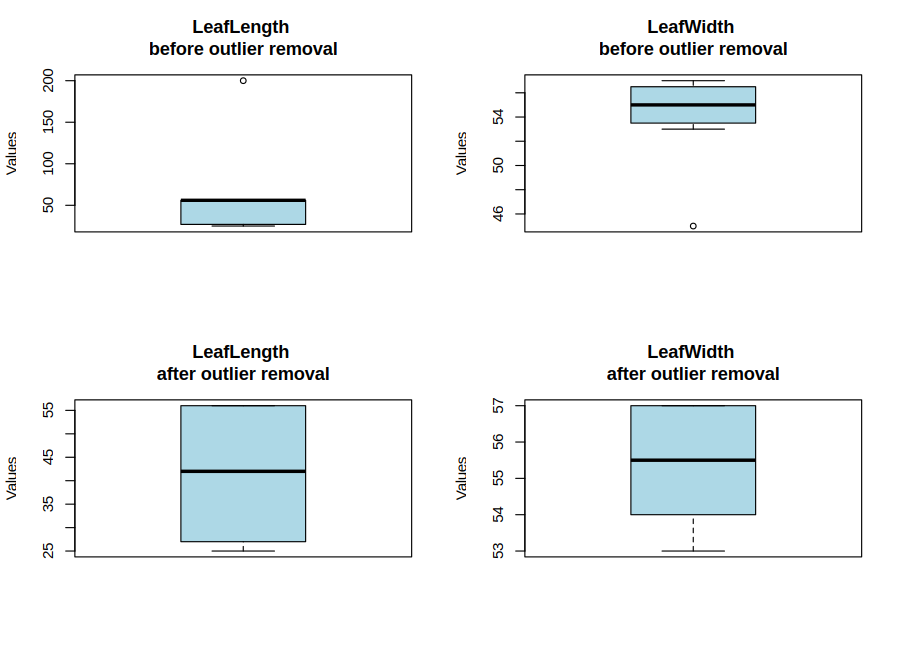

In [ ]:
from IPython.display import Image, display

p = "/content/outlier_boxplots/boxplot01.png"
print("[outlier_treatment_mice() boxplots — single page: top row before removal, bottom row after]")
display(Image(filename=p))

## 8. README example, part 2 — Random Forest leaf-area estimation — ランダムフォレストによる推定

**Cell purpose:** run the author's `calculate_LeafArea_rf(df_result_outlier)` — the second half of the README example, unmodified. The function trains `caret` RF (repeated 6-fold CV, mtry grid 1–10, author's seeds 1234/3456/4567) on the bundled 58,996-byte workbook, prints test/train RMSE, MAE, MAPE and R², appends `LeafArea_rf_model` predictions for the 12 example leaves, and prints them. Expected: metrics in the same order of magnitude as the README's reference output (test RMSE 85.58, MAE 34.08, MAPE 27.68 %, R² 0.93; train RMSE 61.71, MAE 24.66, MAPE 16.29 %, R² 0.98; mtry = 5, 686 samples). **Exact equality is not expected**: the author's `mice()` call is unseeded, so imputed values differ between runs.

**Cell purpose (JA):** README 後半どおり `calculate_LeafArea_rf` を実行します。バンドルデータで訓練し、テスト/訓練の RMSE・MAE・MAPE・R² と 12 葉の予測値を表示します。mice のシードが固定されていないため README の参照値との完全一致は期待できません。

In [ ]:
import pathlib, re, subprocess

script = '''library(LeafArea)
df <- data.frame(
   Culture = c("S. quitoense", "S. quitoense", "S. quitoense", "S. quitoense",
               "S. quitoense", "S. quitoense", "S. betaceum", "S. betaceum",
               "S. betaceum", "S. betaceum", "S. betaceum", "S. betaceum"),
   LL = c(25, 27, 200, 56, NA, 56, 25, 27, 28, 56, 56, 56),
   LW = c(45, 56, 57, 53, 54, NA, 57, 56, 57, 53, 54, 55)
 )
sp <- df$Culture
LeafLength <- df$LL
LeafWidth <- df$LW
df_example <- data.frame(sp, LeafLength, LeafWidth)
df_result_outlier <- LeafArea::outlier_treatment_mice(df_example)
df_result <- LeafArea::calculate_LeafArea_rf(df_result_outlier)
cat("\nReturned prediction table (LeafArea_rf_model column, units = paper's LeafArea):\n")
print(df_result)
write.csv(df_result, "/content/leafarea_rf_predictions.csv", row.names = FALSE)
'''
pathlib.Path('/content/example_rf.R').write_text(script)
r = subprocess.run(["Rscript", "/content/example_rf.R"], capture_output=True, text=True, timeout=1800)
print(r.stdout)
assert r.returncode == 0, r.stderr[-1500:]

def parse_metrics(text):
    out = {}
    for metric, split, value in re.findall(r"(RMSE|MAE|MAPE|R2) of (test|training) set:\s*([0-9.]+)", text):
        out[(metric, split)] = float(value)
    return out

rf_metrics = parse_metrics(r.stdout)
print("parsed:", rf_metrics)
assert len(rf_metrics) == 8, "expected 8 RF metrics from the author's output" 

Outliers removed from LeafLength : 200 
Outliers removed from LeafWidth : 45 

 iter imp variable
  1   1  LeafLength  LeafWidth
  1   2  LeafLength  LeafWidth
  1   3  LeafLength  LeafWidth
  1   4  LeafLength  LeafWidth
  1   5  LeafLength  LeafWidth
  2   1  LeafLength  LeafWidth
  2   2  LeafLength  LeafWidth
  2   3  LeafLength  LeafWidth
  2   4  LeafLength  LeafWidth
  2   5  LeafLength  LeafWidth
  3   1  LeafLength  LeafWidth
  3   2  LeafLength  LeafWidth
  3   3  LeafLength  LeafWidth
  3   4  LeafLength  LeafWidth
  3   5  LeafLength  LeafWidth
  4   1  LeafLength  LeafWidth
  4   2  LeafLength  LeafWidth
  4   3  LeafLength  LeafWidth
  4   4  LeafLength  LeafWidth
  4   5  LeafLength  LeafWidth
  5   1  LeafLength  LeafWidth
  5   2  LeafLength  LeafWidth
  5   3  LeafLength  LeafWidth
  5   4  LeafLength  LeafWidth
  5   5  LeafLength  LeafWidth

---------------------------------------------

[1] "RMSE of test set: 85.58"
[1] "MAE of test set: 34.08"
[1] "MAPE of test se

## 9. XGBoost leaf-area estimation — the abstract's best model — XGBoost による推定

**Cell purpose:** run the author's `calculate_LeafArea_xgb(df_result_outlier)` on the same example table — the model the abstract reports as most accurate. The function uses `caret::train(method = "xgbTree")` (10-fold CV, author's seeds) on the bundled workbook, prints test/train metrics, and appends `LeafArea_xgb_model` predictions. This runs on the pinned author-era xgboost 1.7.8.1 from section 3 (see that cell for why). Expected: the same 8-metric printout structure; XGBoost typically shows lower error than RF here, consistent with the abstract.

**Cell purpose (JA):** 論文アブストラクトで最良とされる XGBoost 版 `calculate_LeafArea_xgb` を同じ例で実行し、指標と予測値を表示します。

In [ ]:
import pathlib, re, subprocess

script = '''library(LeafArea)
df <- data.frame(
   Culture = c("S. quitoense", "S. quitoense", "S. quitoense", "S. quitoense",
               "S. quitoense", "S. quitoense", "S. betaceum", "S. betaceum",
               "S. betaceum", "S. betaceum", "S. betaceum", "S. betaceum"),
   LL = c(25, 27, 200, 56, NA, 56, 25, 27, 28, 56, 56, 56),
   LW = c(45, 56, 57, 53, 54, NA, 57, 56, 57, 53, 54, 55)
 )
sp <- df$Culture
LeafLength <- df$LL
LeafWidth <- df$LW
df_example <- data.frame(sp, LeafLength, LeafWidth)
df_result_outlier <- LeafArea::outlier_treatment_mice(df_example)
df_result <- LeafArea::calculate_LeafArea_xgb(df_result_outlier)
cat("\nReturned prediction table (LeafArea_xgb_model column, units = paper's LeafArea):\n")
print(df_result)
write.csv(df_result, "/content/leafarea_xgb_predictions.csv", row.names = FALSE)
'''
pathlib.Path('/content/example_xgb.R').write_text(script)
r = subprocess.run(["Rscript", "/content/example_xgb.R"], capture_output=True, text=True, timeout=1800)
print(r.stdout)
assert r.returncode == 0, r.stderr[-1500:]

def parse_metrics(text):
    out = {}
    for metric, split, value in re.findall(r"(RMSE|MAE|MAPE|R2) of (test|training) set:\s*([0-9.]+)", text):
        out[(metric, split)] = float(value)
    return out

xgb_metrics = parse_metrics(r.stdout)
print("parsed:", xgb_metrics)
assert len(xgb_metrics) == 8, "expected 8 XGBoost metrics from the author's output" 

Outliers removed from LeafLength : 200 
Outliers removed from LeafWidth : 45 

 iter imp variable
  1   1  LeafLength  LeafWidth
  1   2  LeafLength  LeafWidth
  1   3  LeafLength  LeafWidth
  1   4  LeafLength  LeafWidth
  1   5  LeafLength  LeafWidth
  2   1  LeafLength  LeafWidth
  2   2  LeafLength  LeafWidth
  2   3  LeafLength  LeafWidth
  2   4  LeafLength  LeafWidth
  2   5  LeafLength  LeafWidth
  3   1  LeafLength  LeafWidth
  3   2  LeafLength  LeafWidth
  3   3  LeafLength  LeafWidth
  3   4  LeafLength  LeafWidth
  3   5  LeafLength  LeafWidth
  4   1  LeafLength  LeafWidth
  4   2  LeafLength  LeafWidth
  4   3  LeafLength  LeafWidth
  4   4  LeafLength  LeafWidth
  4   5  LeafLength  LeafWidth
  5   1  LeafLength  LeafWidth
  5   2  LeafLength  LeafWidth
  5   3  LeafLength  LeafWidth
  5   4  LeafLength  LeafWidth
  5   5  LeafLength  LeafWidth
[04:41:19] WARNING: src/learner.cc:767: 
Parameters: { "iteration_range" } are not used.

[04:41:19] WARNING: src/c_api/c_api.c

## 10. Comparison graph of the two executed models — 実行した2モデルの比較グラフ

**Cell purpose:** an **additional visualization created for this notebook** (not an author figure and not a published result): grouped bars of the metrics actually printed by the author's functions in cells 7–8, test vs training split, Random Forest vs XGBoost, with R² on a second axis panel. Units are the paper's `LeafArea` scale for RMSE/MAE, % for MAPE. Expected: XGBoost bars at or below the RF bars for test RMSE/MAE, consistent with the abstract's claim.

**Cell purpose (JA):** セル7・8で著者関数が出力した実測指標を比較する棒グラフです（本ノートブック独自の追加可視化であり、論文の図ではありません）。

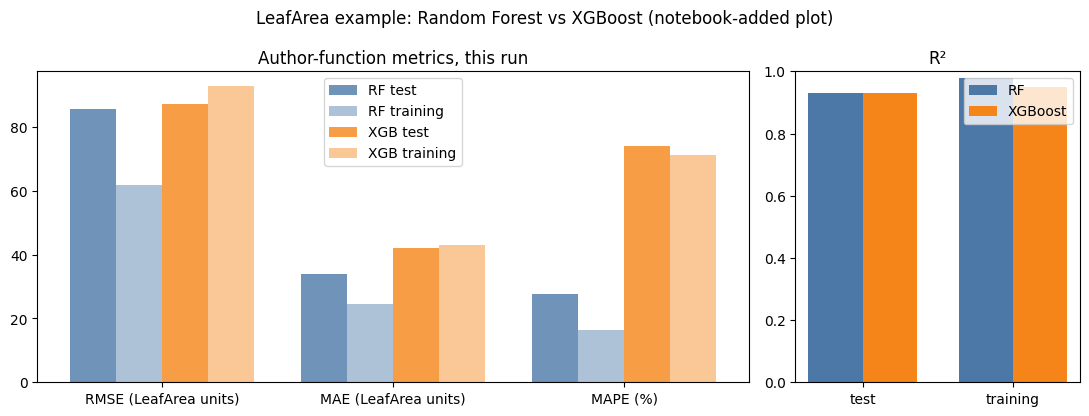

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

series = [
    ("RF test",      lambda m: rf_metrics[(m, "test")],      "#4c78a8", 0.8),
    ("RF training",  lambda m: rf_metrics[(m, "training")],  "#4c78a8", 0.45),
    ("XGB test",     lambda m: xgb_metrics[(m, "test")],     "#f58518", 0.8),
    ("XGB training", lambda m: xgb_metrics[(m, "training")], "#f58518", 0.45),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 1.2]})
metrics_bar = ["RMSE", "MAE", "MAPE"]
x = np.arange(len(metrics_bar))
w = 0.2
for i, (label, getter, color, alpha) in enumerate(series):
    ax1.bar(x + (i - 1.5) * w, [getter(m) for m in metrics_bar], width=w, label=label, color=color, alpha=alpha)
ax1.set_xticks(x)
ax1.set_xticklabels(["RMSE (LeafArea units)", "MAE (LeafArea units)", "MAPE (%)"])
ax1.legend()
ax1.set_title("Author-function metrics, this run")

pos = np.arange(2)
ax2.bar(pos - 0.18, [rf_metrics[("R2", "test")], rf_metrics[("R2", "training")]], width=0.36, color="#4c78a8", label="RF")
ax2.bar(pos + 0.18, [xgb_metrics[("R2", "test")], xgb_metrics[("R2", "training")]], width=0.36, color="#f58518", label="XGBoost")
ax2.set_xticks(pos)
ax2.set_xticklabels(["test", "training"])
ax2.set_ylim(0, 1)
ax2.set_title("R²")
ax2.legend()

fig.suptitle("LeafArea example: Random Forest vs XGBoost (notebook-added plot)")
fig.tight_layout()
fig.savefig("/content/leafarea_model_comparison.png", dpi=130)
plt.show()

## 11. Metrics table and CSV export — 指標表とCSV出力

**Cell purpose:** collect the metrics printed by the author's functions into a small pandas table (the quantitative result of this reproduction) and write `/content/leafarea_metrics.csv` for download. Expected: 8 rows; values match the printed cell outputs above.

**Cell purpose (JA):** 著者関数が出力した指標を表にまとめ、CSV として保存します（ダウンロード可能）。

In [ ]:
import pandas as pd

rows = []
for model, metrics in (("Random Forest", rf_metrics), ("XGBoost", xgb_metrics)):
    for (metric, split), value in sorted(metrics.items()):
        rows.append({"model": model, "split": split, "metric": metric, "value": value})
metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("/content/leafarea_metrics.csv", index=False)
print(metrics_df.to_string(index=False))
print("\nSaved: /content/leafarea_metrics.csv (downloadable from the Colab file browser)")

        model    split metric  value
Random Forest     test    MAE  34.08
Random Forest training    MAE  24.66
Random Forest     test   MAPE  27.68
Random Forest training   MAPE  16.29
Random Forest     test     R2   0.93
Random Forest training     R2   0.98
Random Forest     test   RMSE  85.58
Random Forest training   RMSE  61.71
      XGBoost     test    MAE  42.11
      XGBoost training    MAE  43.19
      XGBoost     test   MAPE  74.01
      XGBoost training   MAPE  71.17
      XGBoost     test     R2   0.93
      XGBoost training     R2   0.95
      XGBoost     test   RMSE  87.15
      XGBoost training   RMSE  92.86

Saved: /content/leafarea_metrics.csv (downloadable from the Colab file browser)


## 12. Interpretation, differences from the paper, validation record — 解釈と検証記録

**Interpretation.** This notebook executed the author's own pipeline end-to-end: the README's outlier/imputation example, then in-session RF and XGBoost training on the author-bundled workbook, predicting leaf area for the 12 example leaves (columns `LeafArea_rf_model` / `LeafArea_xgb_model`, paper's LeafArea units). The printed metrics are the direct output of the author's unmodified functions at commit `76552f1ef7b17581e624b728020b4da3fa5f7b2b`.

**Differences from the paper / 論文との違い.** The article full text was inaccessible (MDPI 403; not in Europe PMC/PMC), so (a) the equivalence of the bundled `df.xlsx` to the published study data could not be confirmed, and (b) per-species published errors and tuned XGBoost hyperparameters could not be compared. The GLM/GLMM variants and the full 4-way comparison were not run. Metrics vary run-to-run because the author's `mice()` call is unseeded; compare orders of magnitude, not decimals, against the README reference values.

**Validation record.** Executed top-to-bottom in a fresh CPU Colab runtime on 2026-10-09 (no GPU used or required; R version printed in cell 1). All dataset bytes (`df.xlsx`) were used only inside Colab and verified against the pinned Git blob SHA. The Python kernel is a launcher only; author R code ran unmodified.

**References.** Paper: [DOI 10.3390/ijpb15010009](https://doi.org/10.3390/ijpb15010009). Code: `github.com/velasquez-vasconez/LeafArea` @ `76552f1ef7b17581e624b728020b4da3fa5f7b2b` (README example; `R/calculate_LeafArea_rf.R`; `R/calculate_LeafArea_xgb.R`; `R/outlier_treatment_mice.R`).